In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
data_path = "Covid Dataset of Bangladesh divisionwise.csv"
covid_data = pd.read_csv(data_path)

In [3]:
covid_data

,Date,Confirmed cases Barisal,Case rate Barisal,Deaths Barisal,Death Rate Barisal,Confirmed cases CTG,Case rate CTG,Deaths CTG,Death Rate CTG,Confirmed cases DHK,...,Deaths Rangpur,Death Rate Rangpur,Confirmed cases Sylhet,Case rate Sylhet,Deaths Sylhet,Death Rate Sylhet,Confirmed cases allover Bangladesh,Case rate allover Bangladesh,Deaths allover Bangladesh,Death Rate allover Bangladesh
0,Mar-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Mar-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Mar-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Mar-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Mar-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484,Jun-21,162.0,34.0,104.0,1.2,988.0,20.0,104.0,1.2,2768.0,...,104.0,1.2,257.0,25.0,104.0,1.2,8364.0,24.0,104.0,1.2
485,Jun-21,174.0,36.0,112.0,1.5,1177.0,23.0,112.0,1.5,2958.0,...,112.0,1.5,234.0,26.0,112.0,1.5,7666.0,24.0,112.0,1.5
486,Jun-21,163.0,38.0,115.0,1.3,1311.0,28.0,115.0,1.3,2843.0,...,115.0,1.3,183.0,24.0,115.0,1.3,8822.0,25.0,115.0,1.3
487,Jul-21,161.0,34.0,143.0,1.7,761.0,26.0,143.0,1.7,2253.0,...,143.0,1.7,275.0,32.0,143.0,1.7,8301.0,26.0,143.0,1.7


In [4]:
covid_data.columns

Index(['Date', 'Confirmed cases Barisal', 'Case rate Barisal',
       'Deaths Barisal', 'Death Rate Barisal', 'Confirmed cases CTG',
       'Case rate CTG', 'Deaths CTG', 'Death Rate CTG', 'Confirmed cases DHK',
       'Case rate DHK', 'Deaths DHK', 'Death Rate DHK',
       'Confirmed cases Khulna', 'Case rate Khulna', 'Deaths Khulna',
       'Death Rate Khulna', 'Confirmed cases MMsingh', 'Case rate MMsingh',
       'Deaths MMsingh', 'Death Rate MMsingh', 'Confirmed cases Rajshahi',
       'Case rate Rajshahi', 'Deaths Rajshahi', 'Death Rate Rajshahi',
       'Confirmed cases Rangpur', 'Case rate Rangpur', 'Deaths Rangpur',
       'Death Rate Rangpur', 'Confirmed cases Sylhet', 'Case rate Sylhet',
       'Deaths Sylhet', 'Death Rate Sylhet',
       'Confirmed cases allover Bangladesh', 'Case rate allover Bangladesh',
       'Deaths allover Bangladesh', 'Death Rate allover Bangladesh'],
      dtype='object')

In [5]:
covid_data.isnull().sum()

Date                                   0
Confirmed cases Barisal               42
Case rate Barisal                     42
Deaths Barisal                        28
Death Rate Barisal                    28
Confirmed cases CTG                   36
Case rate CTG                         36
Deaths CTG                            28
Death Rate CTG                        28
Confirmed cases DHK                   25
Case rate DHK                         25
Deaths DHK                            28
Death Rate DHK                        28
Confirmed cases Khulna                44
Case rate Khulna                      44
Deaths Khulna                         28
Death Rate Khulna                     28
Confirmed cases MMsingh               39
Case rate MMsingh                     39
Deaths MMsingh                        28
Death Rate MMsingh                    28
Confirmed cases Rajshahi              44
Case rate Rajshahi                    44
Deaths Rajshahi                       28
Death Rate Rajsh

In [6]:
covid_data = covid_data.dropna()

In [7]:
covid_data.isnull().sum()

Date                                  0
Confirmed cases Barisal               0
Case rate Barisal                     0
Deaths Barisal                        0
Death Rate Barisal                    0
Confirmed cases CTG                   0
Case rate CTG                         0
Deaths CTG                            0
Death Rate CTG                        0
Confirmed cases DHK                   0
Case rate DHK                         0
Deaths DHK                            0
Death Rate DHK                        0
Confirmed cases Khulna                0
Case rate Khulna                      0
Deaths Khulna                         0
Death Rate Khulna                     0
Confirmed cases MMsingh               0
Case rate MMsingh                     0
Deaths MMsingh                        0
Death Rate MMsingh                    0
Confirmed cases Rajshahi              0
Case rate Rajshahi                    0
Deaths Rajshahi                       0
Death Rate Rajshahi                   0


In [8]:
len(covid_data)

431

In [9]:
covid_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Confirmed cases Barisal,431.0,47.067285,40.469082,1.0,14.5,34.0,74.0,202.0
Case rate Barisal,431.0,14.141531,10.945783,1.0,6.0,11.0,21.0,73.0
Deaths Barisal,431.0,33.654292,22.842509,1.0,18.0,31.0,40.5,143.0
Death Rate Barisal,431.0,1.832483,0.952824,0.1,1.2,1.6,2.2,8.4
Confirmed cases CTG,431.0,290.264501,220.360191,3.0,132.5,230.0,391.0,1311.0
Case rate CTG,431.0,11.475638,7.911942,1.0,5.0,9.0,16.5,54.0
Deaths CTG,431.0,33.654292,22.842509,1.0,18.0,31.0,40.5,143.0
Death Rate CTG,431.0,1.832483,0.952824,0.1,1.2,1.6,2.2,8.4
Confirmed cases DHK,431.0,1019.324826,869.601791,84.0,457.5,900.0,1209.5,5178.0
Case rate DHK,431.0,17.709977,10.661248,3.0,10.0,17.0,23.0,77.0


In [10]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

C:\Users\Thoufiq\anaconda3\lib\site-packages\ipykernel_launcher.py:2: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared
  


array([[<AxesSubplot:title={'center':'Confirmed cases Barisal'}>,
        <AxesSubplot:title={'center':'Case rate Barisal'}>,
        <AxesSubplot:title={'center':'Deaths Barisal'}>,
        <AxesSubplot:title={'center':'Death Rate Barisal'}>,
        <AxesSubplot:title={'center':'Confirmed cases CTG'}>,
        <AxesSubplot:title={'center':'Case rate CTG'}>],
       [<AxesSubplot:title={'center':'Deaths CTG'}>,
        <AxesSubplot:title={'center':'Death Rate CTG'}>,
        <AxesSubplot:title={'center':'Confirmed cases DHK'}>,
        <AxesSubplot:title={'center':'Case rate DHK'}>,
        <AxesSubplot:title={'center':'Deaths DHK'}>,
        <AxesSubplot:title={'center':'Death Rate DHK'}>],
       [<AxesSubplot:title={'center':'Confirmed cases Khulna'}>,
        <AxesSubplot:title={'center':'Case rate Khulna'}>,
        <AxesSubplot:title={'center':'Deaths Khulna'}>,
        <AxesSubplot:title={'center':'Death Rate Khulna'}>,
        <AxesSubplot:title={'center':'Confirmed cases MMsi

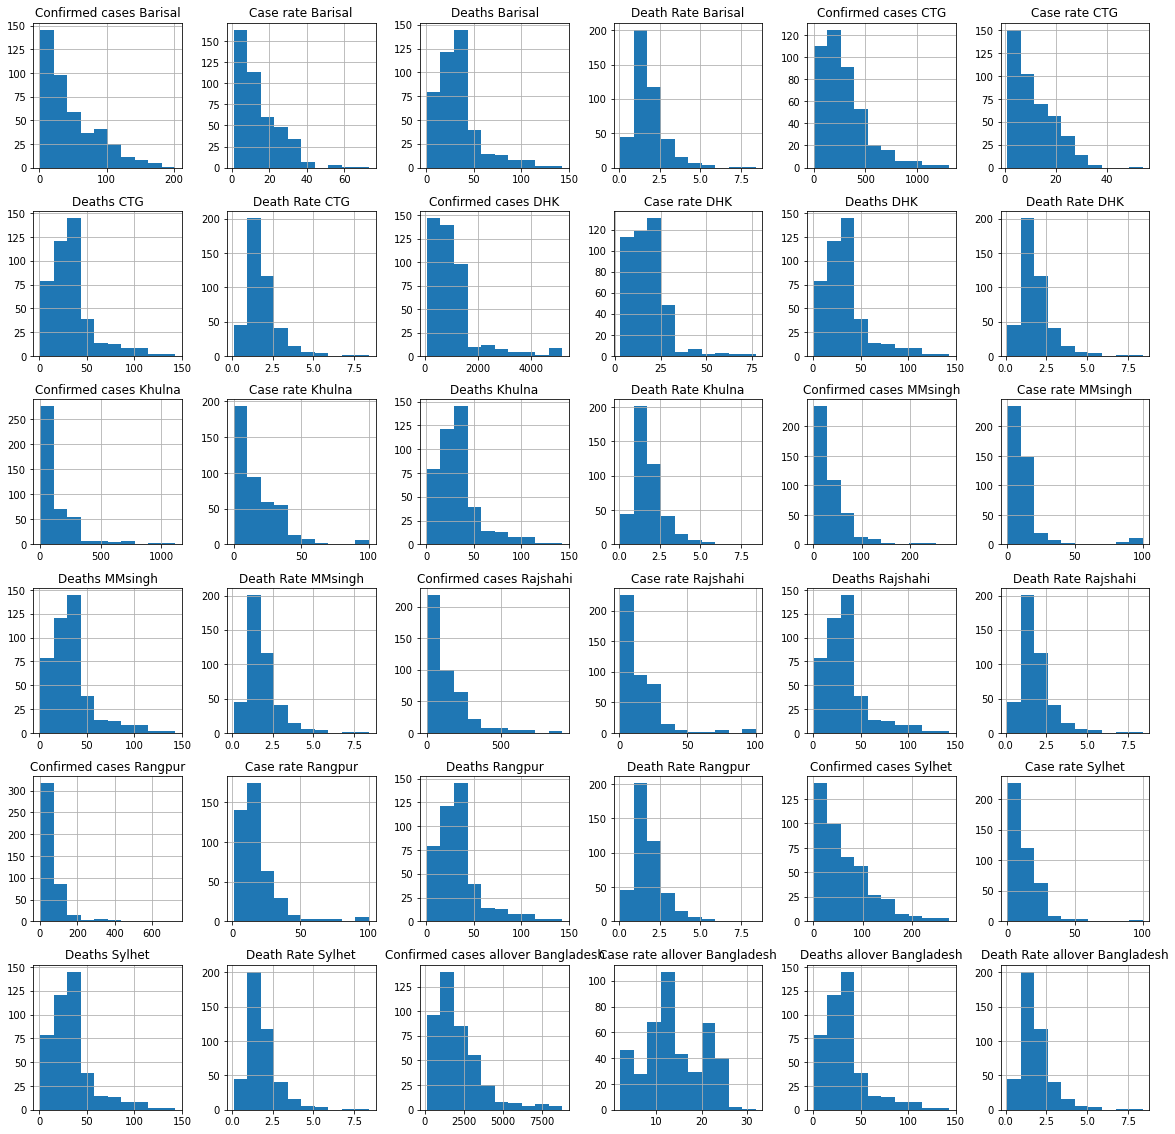

In [11]:
ax = plt.figure(figsize=(20,20))
covid_data.hist(ax = ax)

# Make analysis for Covid in Barisal

In [12]:
barisal_data = covid_data[['Confirmed cases Barisal', 'Case rate Barisal', 'Deaths Barisal', 'Death Rate Barisal','Date']]

In [13]:
barisal_data

,Confirmed cases Barisal,Case rate Barisal,Deaths Barisal,Death Rate Barisal,Date
42,8.0,35.0,4.0,2.9,Apr-20
43,8.0,73.0,5.0,2.7,Apr-20
44,4.0,44.0,7.0,3.3,Apr-20
47,8.0,40.0,15.0,5.6,Apr-20
49,6.0,60.0,7.0,2.2,Apr-20
...,...,...,...,...,...
484,162.0,34.0,104.0,1.2,Jun-21
485,174.0,36.0,112.0,1.5,Jun-21
486,163.0,38.0,115.0,1.3,Jun-21
487,161.0,34.0,143.0,1.7,Jul-21


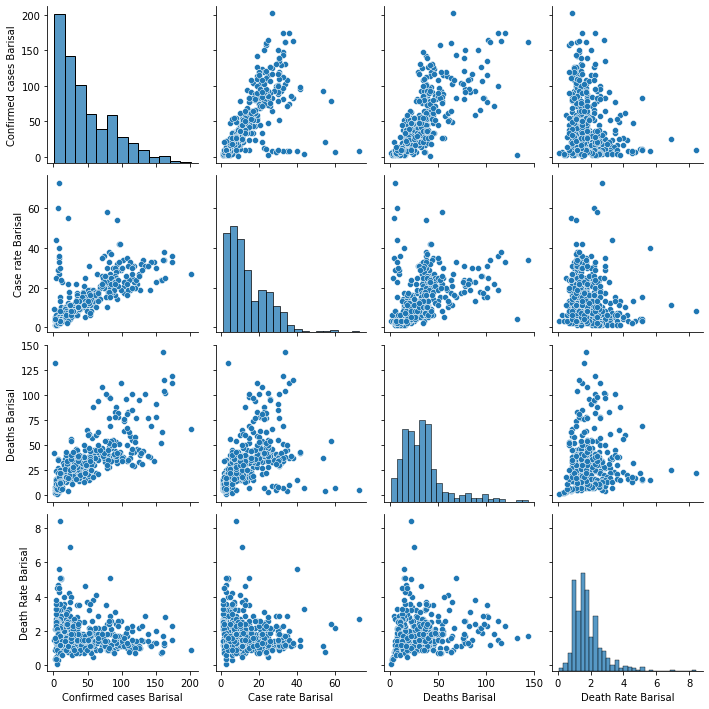

In [14]:
sns.pairplot(barisal_data)

**Analize the Case Rate with Death Rate**

<AxesSubplot:xlabel='Case rate Barisal', ylabel='Death Rate Barisal'>

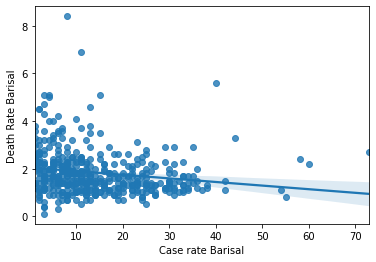

In [15]:
sns.regplot(x=barisal_data['Case rate Barisal'], y=barisal_data['Death Rate Barisal'])

<AxesSubplot:xlabel='Case rate Barisal', ylabel='Death Rate Barisal'>

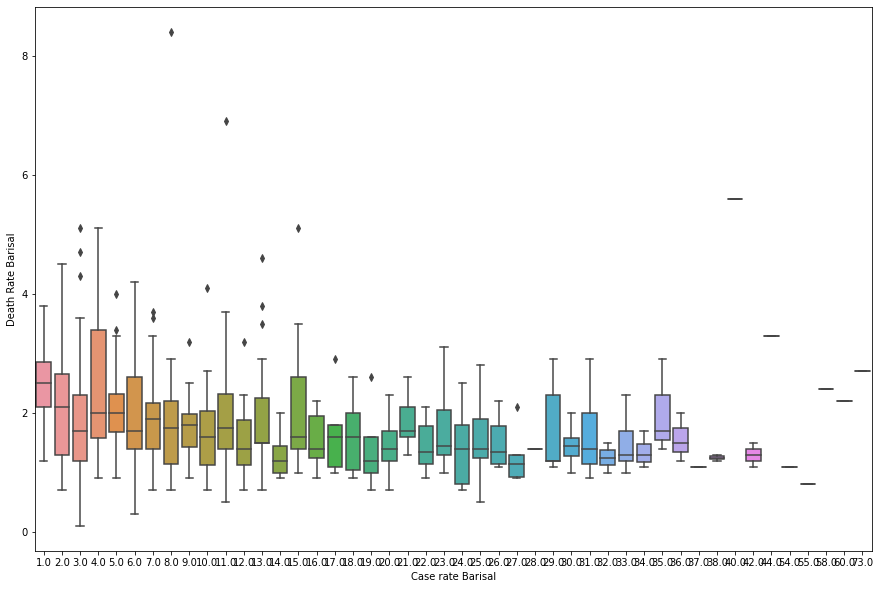

In [16]:
plt.figure(figsize=(15,10))
sns.boxplot(x='Case rate Barisal', y='Death Rate Barisal',data =barisal_data)

<AxesSubplot:xlabel='Case rate Barisal', ylabel='Density'>

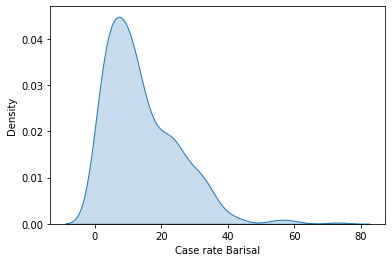

In [17]:
sns.kdeplot(data=barisal_data['Case rate Barisal'],shade=True)

<AxesSubplot:xlabel='Death Rate Barisal', ylabel='Density'>

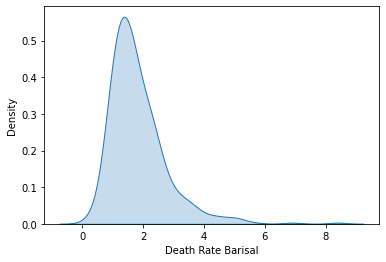

In [18]:
sns.kdeplot(data=barisal_data['Death Rate Barisal'],shade=True)

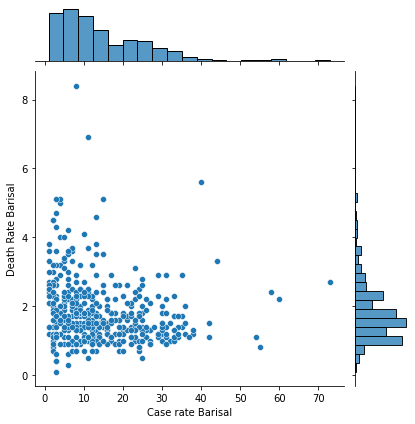

In [19]:
sns.jointplot(x='Case rate Barisal', y='Death Rate Barisal',data =barisal_data)

<AxesSubplot:xlabel='Confirmed cases Barisal', ylabel='Density'>

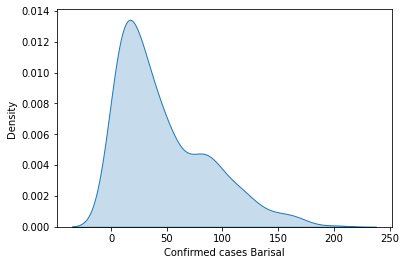

In [20]:
sns.kdeplot(data=barisal_data['Confirmed cases Barisal'],shade=True)

<AxesSubplot:xlabel='Deaths Barisal', ylabel='Density'>

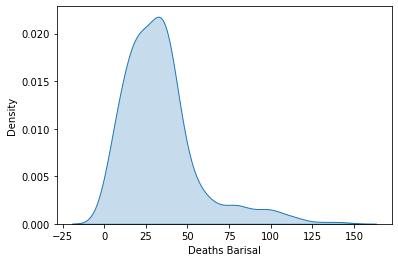

In [21]:
sns.kdeplot(data=barisal_data['Deaths Barisal'],shade=True)

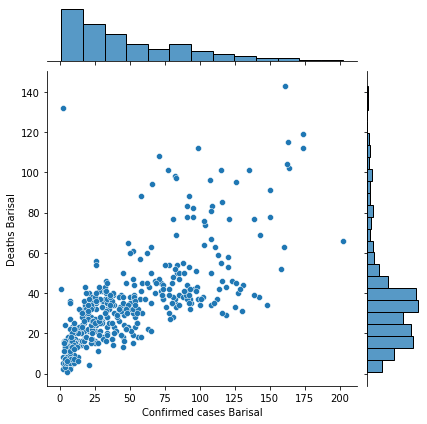

In [22]:
sns.jointplot(x='Confirmed cases Barisal', y='Deaths Barisal',data =barisal_data)

<AxesSubplot:xlabel='Confirmed cases Barisal', ylabel='Deaths Barisal'>

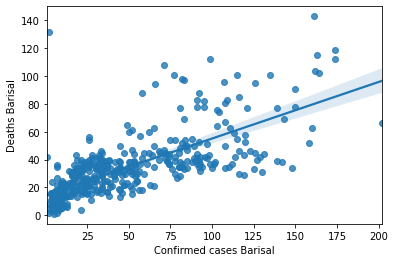

In [23]:
sns.regplot(x='Confirmed cases Barisal', y='Deaths Barisal',data =barisal_data)

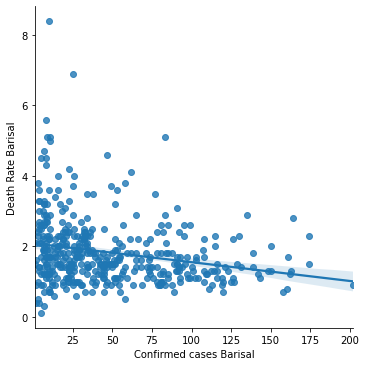

In [24]:
sns.lmplot(x='Confirmed cases Barisal', y='Death Rate Barisal',data =barisal_data)

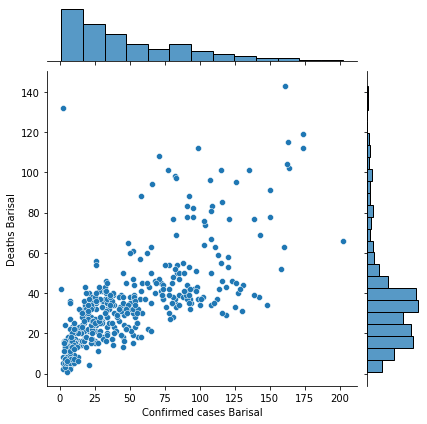

In [25]:
sns.jointplot(x='Confirmed cases Barisal', y='Deaths Barisal',data =barisal_data)

<AxesSubplot:xlabel='Confirmed cases Barisal', ylabel='Case rate Barisal'>

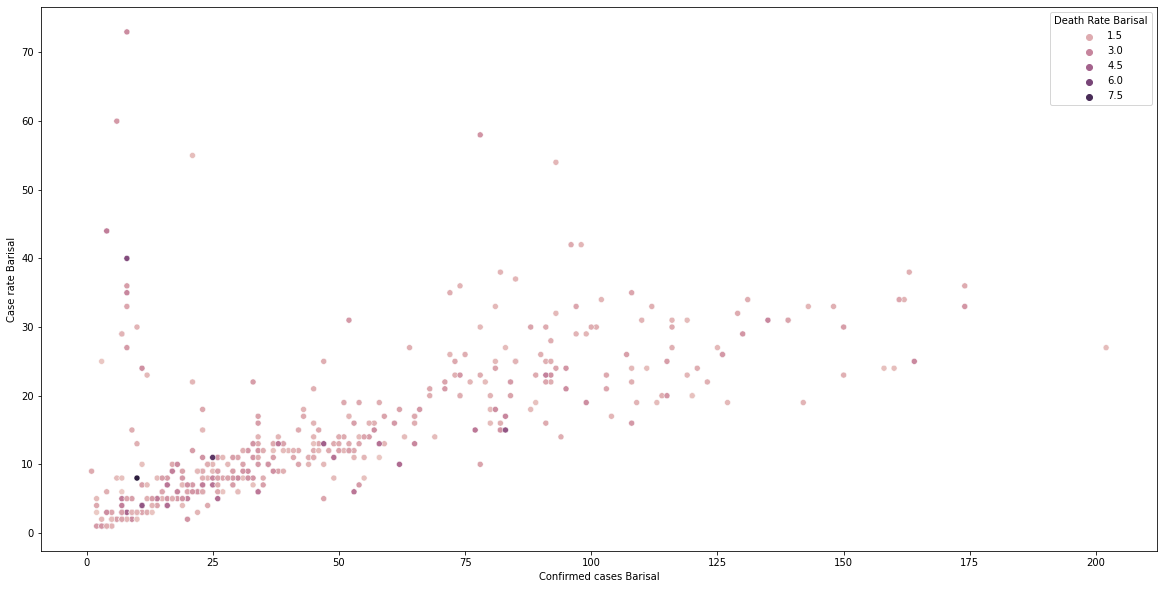

In [26]:
plt.figure(figsize=(20,10))
sns.scatterplot(x='Confirmed cases Barisal', y='Case rate Barisal', hue='Death Rate Barisal',data =barisal_data)

<AxesSubplot:xlabel='Confirmed cases Barisal', ylabel='Case rate Barisal'>

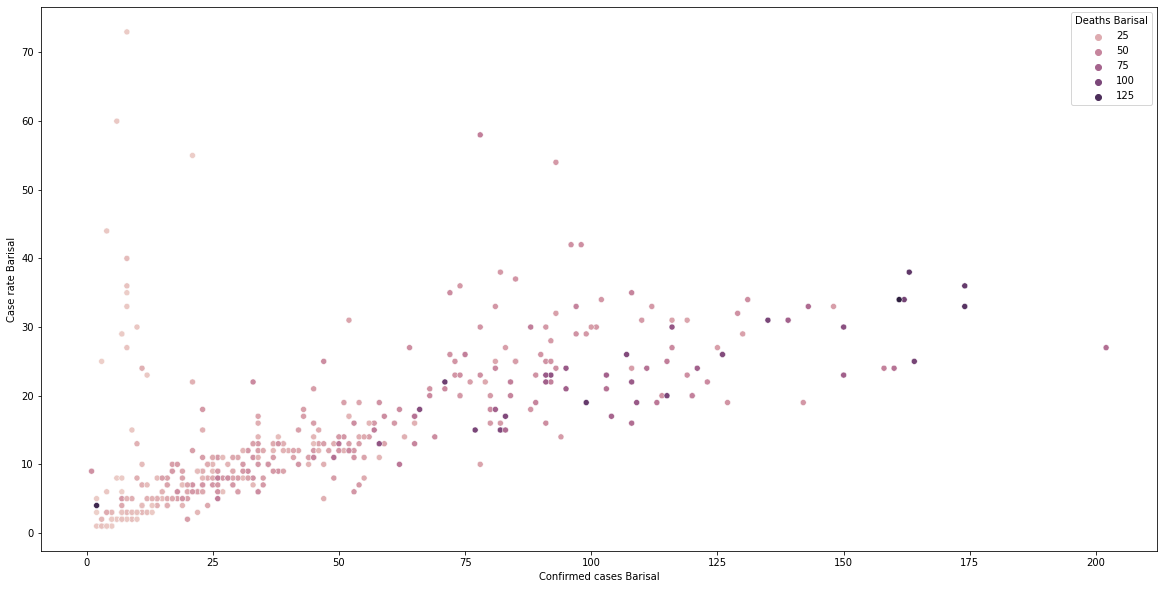

In [27]:
plt.figure(figsize=(20,10))
sns.scatterplot(x='Confirmed cases Barisal', y='Case rate Barisal', hue='Deaths Barisal',data =barisal_data)

<AxesSubplot:xlabel='Date', ylabel='Confirmed cases Barisal'>

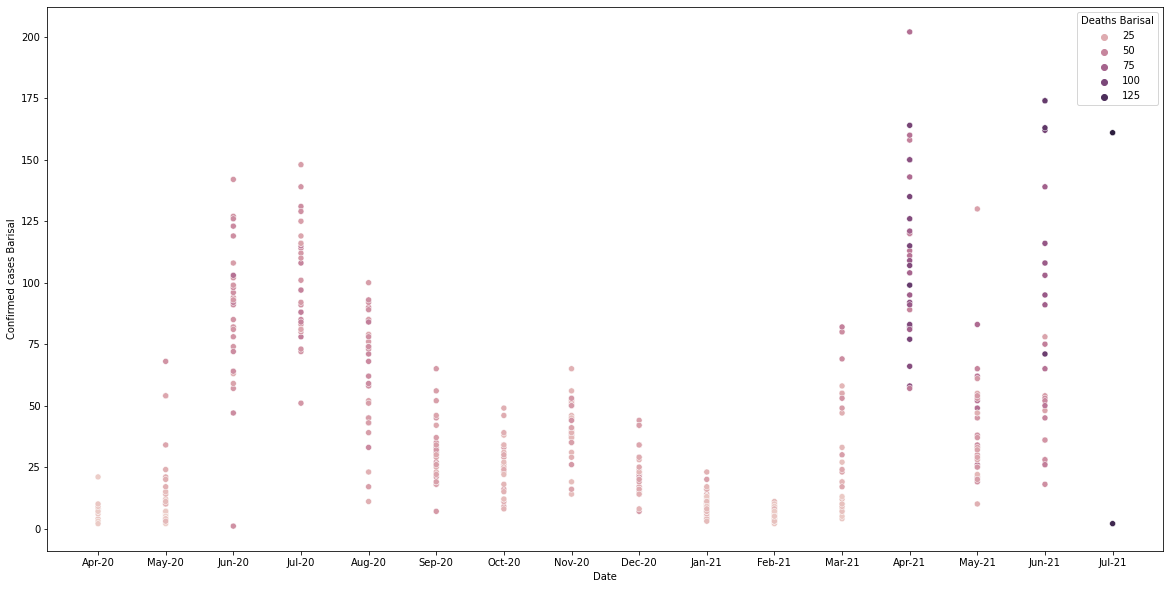

In [28]:
plt.figure(figsize=(20,10))

sns.scatterplot(x='Date', y='Confirmed cases Barisal', hue='Deaths Barisal',data =barisal_data)

<AxesSubplot:xlabel='Date', ylabel='Confirmed cases Barisal'>

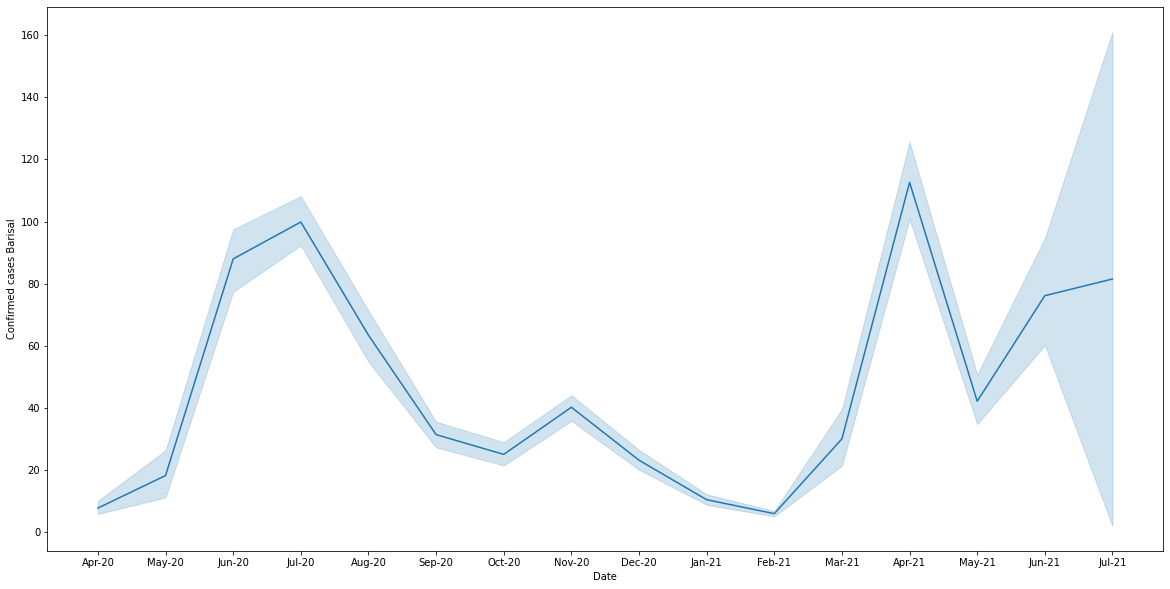

In [29]:
plt.figure(figsize=(20,10))
sns.lineplot(x='Date', y='Confirmed cases Barisal',data =barisal_data)

<AxesSubplot:xlabel='Date', ylabel='Deaths Barisal'>

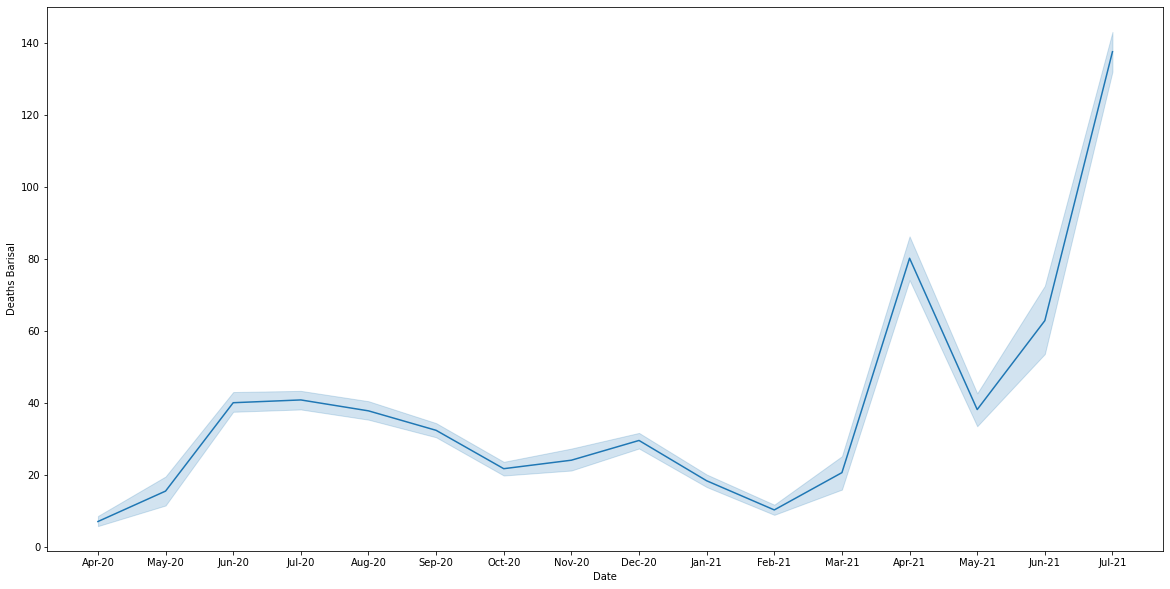

In [30]:
plt.figure(figsize=(20,10))
sns.lineplot(x='Date', y='Deaths Barisal',data =barisal_data)

<AxesSubplot:xlabel='Date', ylabel='Deaths Barisal'>

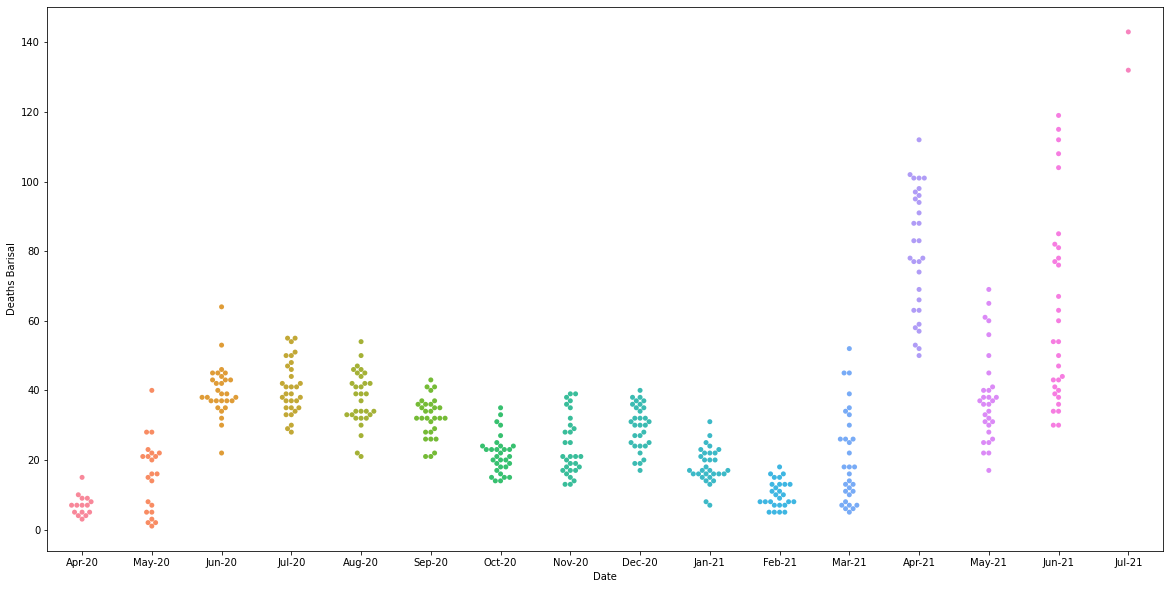

In [31]:
plt.figure(figsize=(20,10))

sns.swarmplot(x='Date', y='Deaths Barisal',data =barisal_data)

C:\Users\Thoufiq\anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 7.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<AxesSubplot:xlabel='Date', ylabel='Confirmed cases Barisal'>

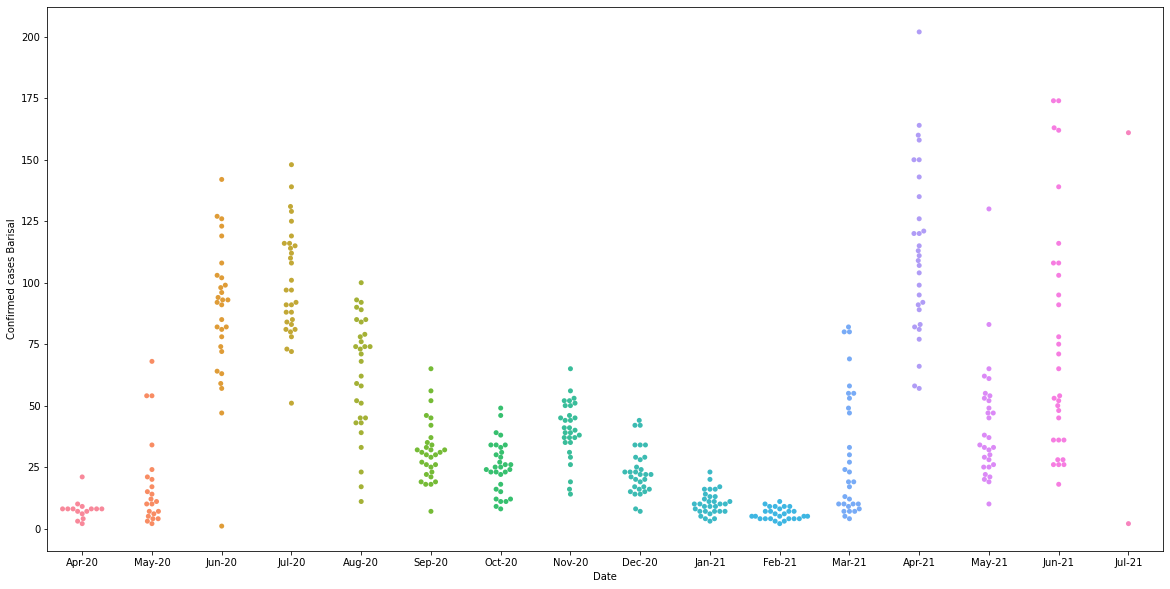

In [32]:
plt.figure(figsize=(20,10))
sns.swarmplot(x='Date', y='Confirmed cases Barisal',data =barisal_data)

<AxesSubplot:xlabel='Date', ylabel='Case rate Barisal'>

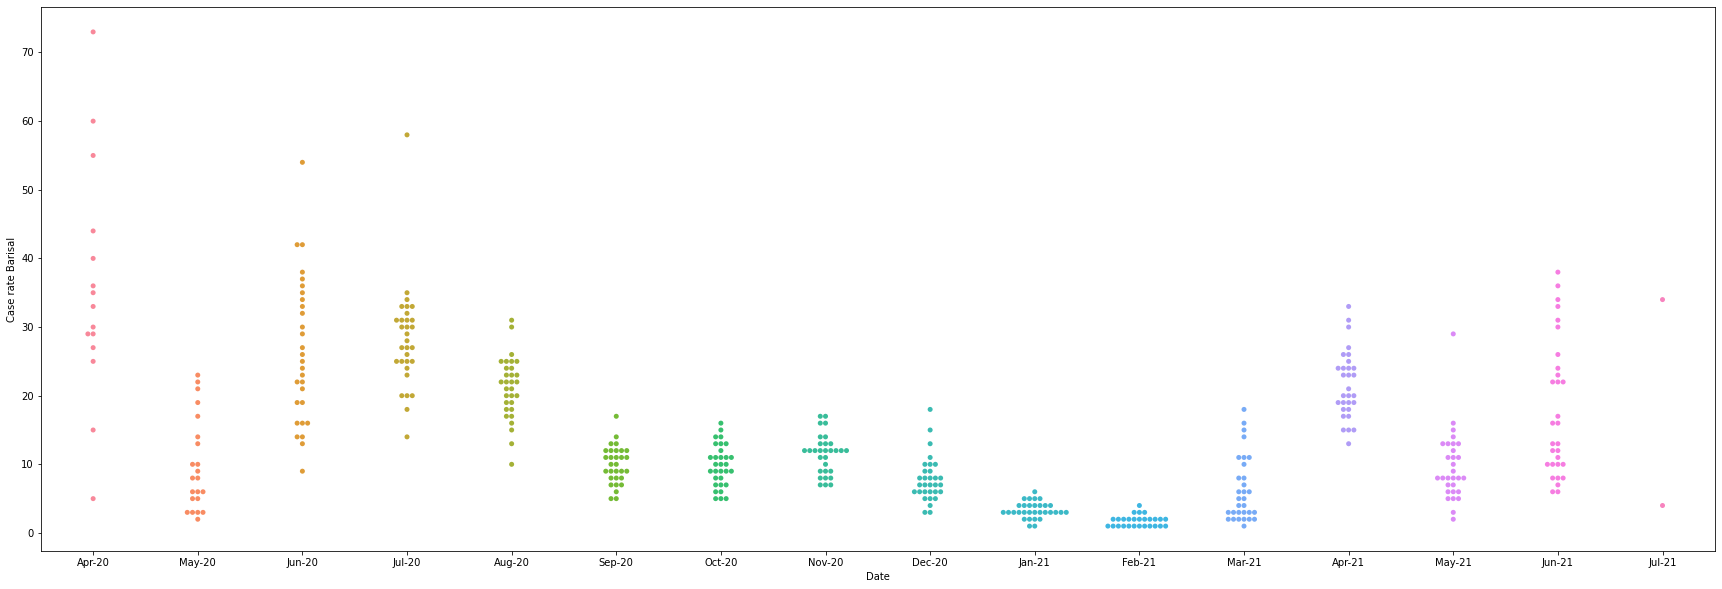

In [33]:
plt.figure(figsize=(30,10))
sns.swarmplot(x='Date', y='Case rate Barisal',data =barisal_data)

# In Barisal between September and March low covid cases and low death cases (i think there was a quarantine :) )

In [ ]:
# Make analysis for Covid in DHK

In [ ]:
CTG_data = covid_data[['Confirmed cases CTG', 'Case rate CTG', 'Deaths CTG', 'Death Rate CTG','Date']]

In [ ]:
CTG_data

In [ ]:
sns.pairplot(CTG_data)

In [ ]:
sns.regplot(x=CTG_data['Case rate CTG'], y=CTG_data['Death Rate CTG'])

In [ ]:
sns.regplot(x='Confirmed cases CTG', y='Deaths CTG',data =CTG_data)

In [ ]:
sns.lmplot(x='Confirmed cases CTG', y='Death Rate CTG',data =CTG_data)

In [ ]:
plt.figure(figsize=(20,10))
sns.lineplot(x='Date', y='Confirmed cases CTG',data =CTG_data)

In [ ]:
plt.figure(figsize=(20,10))
sns.lineplot(x='Date', y='Deaths CTG',data =CTG_data)

In [ ]:
plt.figure(figsize=(20,10))

sns.swarmplot(x='Date', y='Deaths CTG',data =CTG_data)

In [ ]:
plt.figure(figsize=(20,10))
sns.swarmplot(x='Date', y='Confirmed cases CTG',data =CTG_data)

In [ ]:
plt.figure(figsize=(30,10))
sns.swarmplot(x='Date', y='Case rate CTG',data =CTG_data)